# Imports
* Pandas for ETL
* SQLite is a lightweight SQL database

In [132]:
import pandas as pd
import sqlite3

# Create connection
conn = sqlite3.connect("la_sales.sqlite")

# EXTRACT From Data Sources
* Flat Files - read_csv(), read_json(), read_parquent()
     * Append multiple files
* Databases - pd.read_sql() + sqlalchemy
* APIs - tap into web based resources

In [24]:
sales_df = pd.read_csv("LA_Retail_Sales.csv")

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    object 
 1   store_name        750 non-null    object 
 2   product_category  750 non-null    object 
 3   date              750 non-null    object 
 4   Unit sales        745 non-null    float64
 5   DOLLAR SALES      743 non-null    float64
 6   store_zip         750 non-null    object 
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 41.9+ KB


In [26]:
sales_df.head()

,store_id,store_name,product_category,date,Unit sales,DOLLAR SALES,store_zip,promotion_flag
0,LA002,Store_2,Household,9/1/24,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,True
2,LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,True
3,LA003,Store_3,Household,9/7/24,7.0,25.69,90001,True
4,LA008,Store_8,Beverages,9/18/24,25.0,85.46,90005,False


## What if everyday we generated new files, and then in total we have 30 files csv files. How can we read all of those files?

In [51]:
# this will help for file paths in local machine
import glob


file_paths = glob.glob("LA_Retail_Sales_By_Day/*.csv")


# reading the data
sales_df = pd.concat([pd.read_csv(fp) for fp in file_paths], ignore_index=True)

In [57]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    object 
 1   store_name        750 non-null    object 
 2   product_category  750 non-null    object 
 3   date              750 non-null    object 
 4   unit_sales        745 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         750 non-null    object 
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 41.9+ KB


In [72]:
sales_df = pd.DataFrame()

for day in range(1,6):
    print(day)

    day_df = pd.read_csv(f"LA_Retail_Sales_By_Day/sales_2024-09-{day:02d}.csv")
    sales_df = pd.concat([sales_df, day_df])
    print(len(sales_df))

sales_df.info()

1
30
2
57
3
81
4
97
5
120
<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 22
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          120 non-null    object 
 1   store_name        120 non-null    object 
 2   product_category  120 non-null    object 
 3   date              120 non-null    object 
 4   unit_sales        120 non-null    float64
 5   dollar_sales      120 non-null    float64
 6   store_zip         120 non-null    object 
 7   promotion_flag    120 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 7.6+ KB


In [60]:
list(range(1,6))

[1, 2, 3, 4, 5]

## Working with JSON file

In [85]:
# lines=Tue is like helper to read our data correctly so our file actually JSON file but with trailing data so it can cause failure
sales_df = pd.read_json("LA_Retail_Sales.json", lines=True)
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   store_id          750 non-null    object        
 1   store_name        750 non-null    object        
 2   product_category  750 non-null    object        
 3   date              750 non-null    datetime64[ns]
 4   unit_sales        745 non-null    float64       
 5   dollar_sales      743 non-null    float64       
 6   store_zip         750 non-null    object        
 7   promotion_flag    750 non-null    bool          
dtypes: bool(1), datetime64[ns](1), float64(2), object(4)
memory usage: 41.9+ KB


## Working with parquet file

In [96]:
sales_df = pd.read_parquet("LA_Retail_Sales.parquet")
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   store_id          750 non-null    object        
 1   store_name        750 non-null    object        
 2   product_category  750 non-null    object        
 3   date              750 non-null    datetime64[ns]
 4   unit_sales        745 non-null    float64       
 5   dollar_sales      743 non-null    float64       
 6   store_zip         750 non-null    object        
 7   promotion_flag    750 non-null    bool          
dtypes: bool(1), datetime64[ns](1), float64(2), object(4)
memory usage: 41.9+ KB


## Extract from SQL function

In [134]:
pd.read_sql("SELECT * FROM Sales", con=conn)

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit,temp
0,LA002,Store_2,Household,2024-09-01 00:00:00,16,96.28,90004,1,6.02,71.19
1,LA001,Store_1,Beverages,2024-09-01 00:00:00,14,86.63,90004,1,6.19,71.19
2,LA004,Store_4,Produce,2024-09-15 00:00:00,18,298.26,90003,1,16.57,63.91
3,LA003,Store_3,Household,2024-09-07 00:00:00,7,25.69,90001,1,3.67,78.37
4,LA008,Store_8,Beverages,2024-09-18 00:00:00,25,85.46,90005,0,3.42,60.82
...,...,...,...,...,...,...,...,...,...,...
733,LA010,Store_10,Beverages,2024-09-24 00:00:00,46,790.99,90005,1,17.20,66.04
734,LA008,Store_8,Snacks,2024-09-14 00:00:00,23,375.40,90003,0,16.32,64.98
735,LA004,Store_4,Personal Care,2024-09-14 00:00:00,17,225.24,90000,0,13.25,64.98
736,LA009,Store_9,Snacks,2024-09-28 00:00:00,37,406.47,90004,0,10.99,65.03


<Axes: xlabel='store_id'>

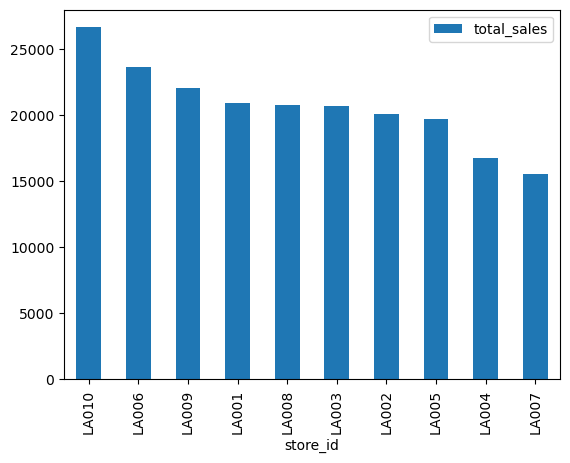

In [144]:
pd.read_sql("""
    SELECT store_id, sum(dollar_sales) as total_sales
    FROM Sales
    GROUP BY store_id
    ORDER BY total_sales DESC
""", con=conn).set_index("store_id").plot.bar()

# set_index() to make specific row as the index
# .plot.bar() draw the barchart

## Extract from API

In [ ]:
pip install openmeteo-requests

In [ ]:
pip install requests-cache retry-requests numpy pandas

In [215]:
import requests # ping API

date = sales_df["date"][0].date()

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 34.0522,
    "longitude": -118.2437,
    "start_date": str(date),
    "end_date": str(date),
    "hourly": "temperature_2m,precipitation,wind_speed_10m",
    "timezone": "America/Los_Angeles"
}

response = requests.get(url, params=params)
# response.status_code
# response.json()

data = response.json()
data

{'latitude': 34.059753,
 'longitude': -118.2375,
 'generationtime_ms': 24.118542671203613,
 'utc_offset_seconds': -25200,
 'timezone': 'America/Los_Angeles',
 'timezone_abbreviation': 'GMT-7',
 'elevation': 91.0,
 'hourly_units': {'time': 'iso8601',
  'temperature_2m': '°C',
  'precipitation': 'mm',
  'wind_speed_10m': 'km/h'},
 'hourly': {'time': ['2024-09-01T00:00',
   '2024-09-01T01:00',
   '2024-09-01T02:00',
   '2024-09-01T03:00',
   '2024-09-01T04:00',
   '2024-09-01T05:00',
   '2024-09-01T06:00',
   '2024-09-01T07:00',
   '2024-09-01T08:00',
   '2024-09-01T09:00',
   '2024-09-01T10:00',
   '2024-09-01T11:00',
   '2024-09-01T12:00',
   '2024-09-01T13:00',
   '2024-09-01T14:00',
   '2024-09-01T15:00',
   '2024-09-01T16:00',
   '2024-09-01T17:00',
   '2024-09-01T18:00',
   '2024-09-01T19:00',
   '2024-09-01T20:00',
   '2024-09-01T21:00',
   '2024-09-01T22:00',
   '2024-09-01T23:00'],
  'temperature_2m': [19.8,
   19.1,
   18.8,
   18.2,
   17.7,
   17.3,
   17.4,
   17.3,
   17.9,


In [153]:
sales_df["date"][0]

Timestamp('2024-09-01 00:00:00')

In [165]:
"""
convert our timestamp to integer value
Year has 4 digits → use %Y (uppercase)
Year has 2 digits → use %y (lowercase)
"""
int(datetime.strptime(str(sales_df["date"][0].date()), "%Y-%m-%d").timestamp())
# 2024-09-01 00:00:00 UTC+8 converted to 2024-08-31 16:00:00 UTC and then convert to int 1725120000

1725120000

In [189]:
response.json()

{'cod': 401,
 'message': 'Please note that using One Call 3.0 requires a separate subscription to the One Call by Call plan. Learn more here https://openweathermap.org/price. If you have a valid subscription to the One Call by Call plan, but still receive this error, then please see https://openweathermap.org/faq#error401 for more info.'}

In [237]:
data["hourly"]["temperature_2m"][0]

19.8

In [239]:
data["hourly"]["precipitation"][0]

0.0

In [241]:
data["hourly"]["wind_speed_10m"][0]

4.1

In [243]:
# sorting the date, drop null/nan and remove duplicates
dates = sales_df["date"].sort_values().dropna().unique()
dates

<DatetimeArray>
['2024-09-01 00:00:00', '2024-09-02 00:00:00', '2024-09-03 00:00:00',
 '2024-09-04 00:00:00', '2024-09-05 00:00:00', '2024-09-06 00:00:00',
 '2024-09-07 00:00:00', '2024-09-08 00:00:00', '2024-09-09 00:00:00',
 '2024-09-10 00:00:00', '2024-09-11 00:00:00', '2024-09-12 00:00:00',
 '2024-09-13 00:00:00', '2024-09-14 00:00:00', '2024-09-15 00:00:00',
 '2024-09-16 00:00:00', '2024-09-17 00:00:00', '2024-09-18 00:00:00',
 '2024-09-19 00:00:00', '2024-09-20 00:00:00', '2024-09-21 00:00:00',
 '2024-09-22 00:00:00', '2024-09-23 00:00:00', '2024-09-24 00:00:00',
 '2024-09-25 00:00:00', '2024-09-26 00:00:00', '2024-09-27 00:00:00',
 '2024-09-28 00:00:00', '2024-09-29 00:00:00', '2024-09-30 00:00:00']
Length: 30, dtype: datetime64[ns]

In [ ]:
# convert to UNIX timestamp (required for historical API)
    unix_timestamp = int(datetime.strptime(str(date.date()), "%Y-%m-%d").timestamp())

In [259]:
from datetime import datetime
import time

# list to store all data returned by API call
weather_data = []

dates = sales_df.date.sort_values().dropna().unique()

for date in dates:

    # convert to UNIX timestamp
    unix_timestamp = int(
        datetime.strptime(
            str(date.date()),
            "%Y-%m-%d"
        ).timestamp()
    )

    params = {
        "latitude": 34.0522,
        "longitude": -118.2437,
        "start_date": str(date.date()),
        "end_date": str(date.date()),
        "hourly": "temperature_2m,precipitation,wind_speed_10m",
        "timezone": "America/Los_Angeles"
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:

        data = response.json()

        day_weather = {
            "date": date.date(),
            "temp": data["hourly"]["temperature_2m"][0],
            "precipitation": data["hourly"]["precipitation"][0],
            "wind_speed": data["hourly"]["wind_speed_10m"][0]
        }

        weather_data.append(day_weather)

    else:
        print(
            f"Failed to fetch data for {date.date()}: "
            f"{response.status_code}"
        )
    # Adds a short waiting period between loops to prevent overwhelming the API server. 
    # If we hit it too fast, we risk getting temporarily blacklisted for seeming like a bot.
    time.sleep(1)

weather_df = pd.DataFrame(weather_data)

In [263]:
weather_df.head()

,date,temp,precipitation,wind_speed
0,2024-09-01,19.8,0.0,4.1
1,2024-09-02,20.4,0.0,3.3
2,2024-09-03,21.4,0.0,2.9
3,2024-09-04,21.8,0.0,9.7
4,2024-09-05,25.5,0.0,9.9


In [265]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           30 non-null     object 
 1   temp           30 non-null     float64
 2   precipitation  30 non-null     float64
 3   wind_speed     30 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.1+ KB


In [271]:
# weather_df.set_index("date").plot.line()

## TRANSFORM Pandas Data

In [279]:
sales_df = pd.read_csv("LA_Retail_Sales.csv")
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    object 
 1   store_name        750 non-null    object 
 2   product_category  750 non-null    object 
 3   date              750 non-null    object 
 4   Unit sales        745 non-null    float64
 5   DOLLAR SALES      743 non-null    float64
 6   store_zip         750 non-null    object 
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 41.9+ KB


### Making our column consistent

In [323]:
# making our column name consistent
sales_df.columns.str.lower().str.replace(" ", "-")

Index(['store_id', 'store_name', 'product_category', 'date', 'unit_sales',
       'dollar-sales', 'store_zip', 'promotion_flag'],
      dtype='object')

In [394]:
sales_df = sales_df.rename(columns={"Unit sales" : "unit_sales", "DOLLAR SALES" : "dollar_sales"})

In [396]:
sales_df.head()

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit
0,LA002,Store_2,Household,9/1/24,16.0,96.28,90004,True,6.017500
1,LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,True,6.187857
2,LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,True,16.570000
3,LA003,Store_3,Household,9/7/24,7.0,25.69,90001,True,3.670000
4,LA008,Store_8,Beverages,9/18/24,25.0,85.46,90005,False,3.418400


In [347]:
missing_unit_indices = sales_df.query("unit_sales.isna()").index

sales_df["unit_sales"] = sales_df["unit_sales"].fillna(0)

sales_df.iloc[missing_unit_indices]

# .read() : Used to load data into a DataFrame.
# .query() : Used to filter data that is already inside a DataFrame.

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    object 
 1   store_name        750 non-null    object 
 2   product_category  750 non-null    object 
 3   date              750 non-null    object 
 4   unit_sales        750 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         750 non-null    object 
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 41.9+ KB


In [371]:
# REMOVE THE MISSING ROWS/values
sales_df = sales_df.dropna(subset=["unit_sales", "dollar_sales"])
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 743 entries, 0 to 749
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          743 non-null    object 
 1   store_name        743 non-null    object 
 2   product_category  743 non-null    object 
 3   date              743 non-null    object 
 4   unit_sales        743 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         743 non-null    object 
 7   promotion_flag    743 non-null    bool   
 8   rev_per_unit      743 non-null    float64
dtypes: bool(1), float64(3), object(5)
memory usage: 53.0+ KB


In [373]:
sales_df["rev_per_unit"] = sales_df["dollar_sales"] / sales_df["unit_sales"].round(2) # round to 2 decimal places

sales_df.head()

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit
0,LA002,Store_2,Household,9/1/24,16.0,96.28,90004,True,6.017500
1,LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,True,6.187857
2,LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,True,16.570000
3,LA003,Store_3,Household,9/7/24,7.0,25.69,90001,True,3.670000
4,LA008,Store_8,Beverages,9/18/24,25.0,85.46,90005,False,3.418400


In [375]:
"""
If you're working with Los Angeles sales data, a zip_code column probably tells you which geographic area the sale/customer/store belongs to.
.store_zip → accesses the store_zip column.
.value_counts() → counts how many times each unique value appears in that column.
"""
sales_df.store_zip.value_counts()


store_zip
90003    137
90004    135
90001    124
90005    122
900XX    118
90002    107
Name: count, dtype: int64

In [381]:
sales_df["store_zip"] = sales_df["store_zip"].str.replace('XX', '00')
sales_df

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit
0,LA002,Store_2,Household,9/1/24,16.0,96.28,90004,True,6.017500
1,LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,True,6.187857
2,LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,True,16.570000
3,LA003,Store_3,Household,9/7/24,7.0,25.69,90001,True,3.670000
4,LA008,Store_8,Beverages,9/18/24,25.0,85.46,90005,False,3.418400
...,...,...,...,...,...,...,...,...,...
745,LA010,Store_10,Beverages,9/24/24,46.0,790.99,90005,True,17.195435
746,LA008,Store_8,Snacks,9/14/24,23.0,375.40,90003,False,16.321739
747,LA004,Store_4,Personal Care,9/14/24,17.0,225.24,90000,False,13.249412
748,LA009,Store_9,Snacks,9/28/24,37.0,406.47,90004,False,10.985676


## Fixing data type

In [410]:
sales_df["date"] = pd.to_datetime(sales_df["date"], format="mixed")
sales_df["promotion_flag"] = sales_df["promotion_flag"].astype(bool)
sales_df["unit_sales"] = sales_df["unit_sales"].astype(int)
sales_df["dollar_sales"] = sales_df["dollar_sales"].astype(float)
sales_df.dtypes
sales.info()

store_id                    object
store_name                  object
product_category            object
date                datetime64[ns]
unit_sales                   int32
dollar_sales               float64
store_zip                   object
promotion_flag                bool
rev_per_unit               float64
dtype: object

In [415]:
"""
is used to get a statistical summary of numerical columns in your DataFrame.

It typically shows:
count → number of non-missing values
mean → average
std → standard deviation
min → minimum
25% → first quartile
50% → median
75% → third quartile
max → maximum
"""
sales_df.describe()

,date,unit_sales,dollar_sales,rev_per_unit
count,743,743.000000,743.000000,743.000000
mean,2024-09-15 12:20:20.995962368,25.464334,279.496729,inf
min,2024-09-01 00:00:00,0.000000,5.330000,2.032340
25%,2024-09-08 12:00:00,13.000000,104.920000,6.575342
50%,2024-09-16 00:00:00,25.000000,224.690000,10.861905
75%,2024-09-23 00:00:00,38.000000,407.095000,15.401379
max,2024-09-30 00:00:00,50.000000,980.000000,inf
std,NaN,14.457709,217.190090,NaN


<Axes: ylabel='Frequency'>

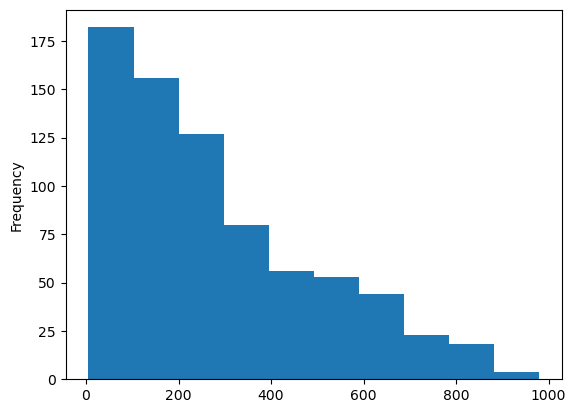

In [417]:
sales_df.dollar_sales.plot.hist()

<Axes: xlabel='dollar_sales', ylabel='Count'>

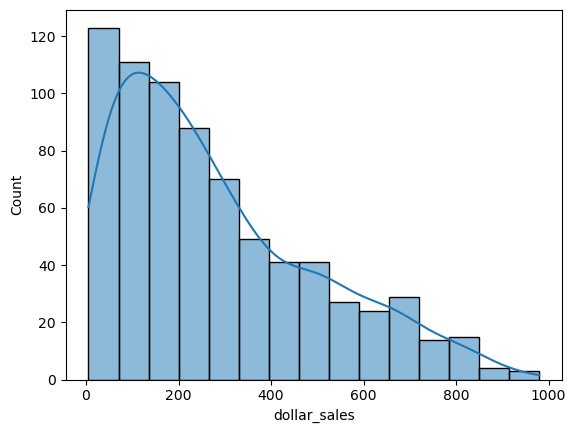

In [421]:
import seaborn as sns

sns.histplot(data=sales_df, x = "dollar_sales", kde=True)
"""
sns is the common alias for Seaborn, a Python library used for statistical data visualization.
KDE = Kernel Density Estimate. It adds a smooth curve over the histogram to show the estimated distribution/shape of the data.
"""

### MERGE API DATA

In [445]:
sales_df = sales_df.merge(weather_df[["date", "temp"]], how="left", on="date")

In [439]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           30 non-null     object 
 1   temp           30 non-null     float64
 2   precipitation  30 non-null     float64
 3   wind_speed     30 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.1+ KB


In [441]:
weather_df["date"] = pd.to_datetime(weather_df["date"], format="mixed")

In [443]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           30 non-null     datetime64[ns]
 1   temp           30 non-null     float64       
 2   precipitation  30 non-null     float64       
 3   wind_speed     30 non-null     float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 1.1 KB


# LOAD INTO SQL

In [447]:
sales_df.to_sql("Sales", if_exists="replace", index=False, con=conn)

743